In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q torcheval loguru scikit-learn

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            # Move annotations to expected location
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step1 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP1_OUTPUT = f"{DRIVE_BASE}/extension_data/step_embeddings_gt.pkl"
    LOCAL_STEP1_OUTPUT = "extension_data/step_embeddings_gt.pkl"

    if os.path.exists(DRIVE_STEP1_OUTPUT) and not os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Copying step1 output from Drive...")
        !cp "{DRIVE_STEP1_OUTPUT}" "{LOCAL_STEP1_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Step1 output already exists locally.")
    else:
        print("WARNING: Step1 output not found. Run extension_step1 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 952, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 952 (delta 118), reused 112 (delta 96), pack-reused 786 (from 2)
Receiving objects: 100% (952/952), 97.86 MiB | 32.48 MiB/s, done.
Resolving deltas: 100% (508/508), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 7.21 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

In [2]:
import pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, balanced_accuracy_score
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Processed Data from Substep 1

In [3]:
# Load data from Substep 1
DATA_PATH = "extension_data/step_embeddings_gt.pkl"

if IN_COLAB:
    DRIVE_DATA_PATH = "/content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl"
    if os.path.exists(DRIVE_DATA_PATH):
        DATA_PATH = DRIVE_DATA_PATH

if os.path.exists(DATA_PATH):
    with open(DATA_PATH, 'rb') as f:
        loaded_data = pickle.load(f)

    processed_data = loaded_data['data']
    splits = loaded_data['splits']
    print(f"Loaded {len(processed_data)} recordings")
else:
    print(f"Data not found at {DATA_PATH}")
    print("Please run extension_step1_localization.ipynb first!")

Loaded 384 recordings


In [ ]:
# Get feature dimension from data
sample_key = list(processed_data.keys())[0]
FEATURE_DIM = processed_data[sample_key]['step_embeddings'].shape[1]
print(f"Feature dimension: {FEATURE_DIM}")

# Group recordings by recipe type
recipe_groups = defaultdict(list)
for recording_id, data in processed_data.items():
    recipe_id = data['recipe_id']
    recipe_groups[recipe_id].append(recording_id)

print(f"\nNumber of unique recipes: {len(recipe_groups)}")
for recipe_id, recordings in list(recipe_groups.items())[:5]:
    labels = [processed_data[r]['recipe_label'] for r in recordings]
    print(f"  Recipe {recipe_id}: {len(recordings)} recordings ({sum(labels)} with errors)")

Feature dimension: 256

Number of unique recipes: 24
  Recipe 1: 18 recordings (13 with errors)
  Recipe 10: 12 recordings (8 with errors)
  Recipe 12: 18 recordings (7 with errors)
  Recipe 13: 14 recordings (9 with errors)
  Recipe 15: 15 recordings (10 with errors)


## 2. Define Dataset and Models

In [ ]:
class TaskVerificationDataset(Dataset):
    """
    Dataset for Task Verification.
    Each sample is a sequence of step embeddings with a recipe-level label.
    """
    def __init__(self, recording_ids, processed_data, max_steps=50):
        self.recording_ids = recording_ids
        self.processed_data = processed_data
        self.max_steps = max_steps

    def __len__(self):
        return len(self.recording_ids)

    def __getitem__(self, idx):
        recording_id = self.recording_ids[idx]
        data = self.processed_data[recording_id]

        step_emb = data['step_embeddings']  # (num_steps, feature_dim)
        label = data['recipe_label']

        # Pad or truncate to max_steps
        num_steps = step_emb.shape[0]
        feature_dim = step_emb.shape[1]

        if num_steps > self.max_steps:
            step_emb = step_emb[:self.max_steps]
            mask = np.ones(self.max_steps)
        else:
            padded = np.zeros((self.max_steps, feature_dim))
            padded[:num_steps] = step_emb
            step_emb = padded
            mask = np.zeros(self.max_steps)
            mask[:num_steps] = 1

        return {
            'embeddings': torch.FloatTensor(step_emb),
            'mask': torch.FloatTensor(mask),
            'label': torch.FloatTensor([label]),
            'num_steps': num_steps
        }


def collate_fn(batch):
    return {
        'embeddings': torch.stack([x['embeddings'] for x in batch]),
        'mask': torch.stack([x['mask'] for x in batch]),
        'label': torch.stack([x['label'] for x in batch]),
        'num_steps': [x['num_steps'] for x in batch]
    }

In [ ]:
class MLPTaskVerifier(nn.Module):
    """MLP baseline: Pool step embeddings then classify."""

    def __init__(self, feature_dim, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(feature_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, embeddings, mask):
        # embeddings: (batch, max_steps, feature_dim)
        # mask: (batch, max_steps)

        # Masked mean pooling
        mask_expanded = mask.unsqueeze(-1)  # (batch, max_steps, 1)
        masked_emb = embeddings * mask_expanded
        pooled = masked_emb.sum(dim=1) / mask.sum(dim=1, keepdim=True).clamp(min=1)

        # MLP
        x = F.relu(self.layer_norm(self.fc1(pooled)))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x


class TransformerTaskVerifier(nn.Module):
    """Transformer baseline for task verification."""

    def __init__(self, feature_dim, hidden_dim=256, num_heads=4, num_layers=2, dropout=0.3, max_steps=50):
        super().__init__()

        # Projection
        self.input_proj = nn.Linear(feature_dim, hidden_dim)

        # Positional encoding
        self.pos_encoding = nn.Parameter(torch.randn(1, max_steps, hidden_dim) * 0.02)

        # CLS token for classification
        self.cls_token = nn.Parameter(torch.randn(1, 1, hidden_dim) * 0.02)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, embeddings, mask):
        batch_size = embeddings.shape[0]

        # Project input
        x = self.input_proj(embeddings)  # (batch, max_steps, hidden_dim)

        # Add positional encoding
        x = x + self.pos_encoding[:, :x.shape[1], :]

        # Prepend CLS token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        # Update mask for CLS token
        cls_mask = torch.ones(batch_size, 1, device=mask.device)
        full_mask = torch.cat([cls_mask, mask], dim=1)

        # Create attention mask (True = ignore)
        attn_mask = (full_mask == 0)

        # Transformer forward
        x = self.transformer(x, src_key_padding_mask=attn_mask)

        # Use CLS token for classification
        cls_output = x[:, 0, :]

        return self.classifier(cls_output)


class LSTMTaskVerifier(nn.Module):
    """LSTM baseline for task verification."""

    def __init__(self, feature_dim, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, embeddings, mask):
        # Pack padded sequence for efficient LSTM
        lengths = mask.sum(dim=1).long()
        lengths = lengths.clamp(min=1)  # Avoid zero lengths

        # Sort by length for packing
        sorted_lengths, sort_idx = lengths.sort(descending=True)
        sorted_emb = embeddings[sort_idx]

        # Pack
        packed = nn.utils.rnn.pack_padded_sequence(
            sorted_emb, sorted_lengths.cpu(), batch_first=True, enforce_sorted=True
        )

        # LSTM forward
        _, (h_n, _) = self.lstm(packed)

        # Concatenate forward and backward hidden states
        hidden = torch.cat([h_n[-2], h_n[-1]], dim=-1)

        # Unsort
        _, unsort_idx = sort_idx.sort()
        hidden = hidden[unsort_idx]

        return self.classifier(hidden)

## 3. Training Functions

In [4]:
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in dataloader:
        embeddings = batch['embeddings'].to(device)
        mask = batch['mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(embeddings, mask)
        loss = criterion(outputs, labels)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.extend(preds.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(embeddings, mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    return total_loss / len(dataloader), np.array(all_preds), np.array(all_labels)


def compute_metrics(preds, labels, threshold=0.5, majority_class=None):
    """Metrics for one fold.

    Reports balanced accuracy and a majority-class baseline alongside F1 because
    F1 alone is misleading on this task. The recipe-level labels are imbalanced
    (57.2% "incorrect" across the 384 recordings used here), so a model that
    predicts "incorrect" for everything scores F1 72.8% while learning nothing.
    F1 far above accuracy with AUC near 50% is that degenerate case, not a result.
    """
    binary_preds = (preds >= threshold).astype(int)
    labels = np.asarray(labels).astype(int)

    metrics = {
        'accuracy': accuracy_score(labels, binary_preds),
        'balanced_accuracy': balanced_accuracy_score(labels, binary_preds),
        'precision': precision_score(labels, binary_preds, zero_division=0),
        'recall': recall_score(labels, binary_preds, zero_division=0),
        'f1': f1_score(labels, binary_preds, zero_division=0),
    }

    try:
        metrics['auc'] = roc_auc_score(labels, preds)
    except Exception:
        metrics['auc'] = 0.5

    # Majority-class baseline. `majority_class` MUST come from the training split -
    # inferring it from `labels` here would peek at the test fold and produce the best
    # possible constant predictor for that fold, which is not a baseline you could
    # actually deploy. Falls back to the test majority only if not supplied, and that
    # fallback is optimistic by construction.
    if len(labels) > 0:
        majority = int(majority_class) if majority_class is not None \
                   else int(np.round(labels.mean()))
        maj_preds = np.full_like(labels, majority)
        metrics['majority_f1'] = f1_score(labels, maj_preds, zero_division=0)
        metrics['majority_accuracy'] = accuracy_score(labels, maj_preds)
        metrics['positive_rate'] = float(labels.mean())
    else:
        metrics['majority_f1'] = 0.0
        metrics['majority_accuracy'] = 0.0
        metrics['positive_rate'] = 0.0

    return metrics

## 4. Leave-One-Recipe-Out Evaluation

In [ ]:
def _fit_scaler(processed_data, ids):
    """Per-dimension mean/std from the TRAINING fold only.

    The step embeddings are not centred or scaled - per-dimension means run from -3.7
    to +2.4 with |mean| ~0.72 - and MLPTaskVerifier applies LayerNorm only AFTER fc1,
    so fc1 itself sees raw, off-centre inputs. Every scikit-learn model that reaches
    ~62% AUC on these same folds standardises first; the unscaled torch models sat at
    42-50% AUC. Statistics come from training recordings only, never val or test.
    """
    X = np.stack([np.asarray(processed_data[r]['step_embeddings'], dtype=np.float32).reshape(-1,
                  np.asarray(processed_data[r]['step_embeddings']).shape[-1]).mean(0) for r in ids])
    mu = X.mean(0)
    sd = X.std(0)
    sd[sd < 1e-6] = 1.0
    return mu.astype(np.float32), sd.astype(np.float32)


def _apply_scaler(processed_data, ids, mu, sd):
    """Return a shallow copy of the entries in `ids` with embeddings standardised."""
    out = {}
    for r in ids:
        e = np.asarray(processed_data[r]['step_embeddings'], dtype=np.float32)
        out[r] = dict(processed_data[r])
        out[r]['step_embeddings'] = (e - mu) / sd
    return out


def _pick_threshold(val_preds, val_labels, metric='balanced_accuracy'):
    """Choose a decision threshold on the VALIDATION fold.

    0.5 is only the right threshold if the model is well calibrated. It is not here:
    with a majority-positive dataset the model pushed every probability above 0.5 and
    collapsed to a constant predictor (recall 1.00, balanced accuracy 0.50). Tuning on
    validation is legitimate - those recipes are held out of both training and test.

    Optimises balanced accuracy by default, deliberately: maximising F1 on an
    imbalanced set rewards the same all-positive degenerate solution we are trying
    to escape, whereas balanced accuracy penalises it directly.
    """
    val_labels = np.asarray(val_labels).astype(int)
    val_preds = np.asarray(val_preds, dtype=float)
    if len(np.unique(val_labels)) < 2:
        return 0.5, None                      # single-class validation fold: no signal
    grid = np.unique(np.concatenate([np.linspace(0.05, 0.95, 19),
                                     np.round(val_preds, 4)]))
    best_t, best_s = 0.5, -np.inf
    for t in grid:
        p = (val_preds >= t).astype(int)
        s = (f1_score(val_labels, p, zero_division=0) if metric == 'f1'
             else balanced_accuracy_score(val_labels, p))
        if s > best_s:
            best_s, best_t = s, float(t)
    return best_t, best_s


def leave_one_recipe_out_eval(model_class, processed_data, recipe_groups,
                               feature_dim, num_epochs=20, lr=1e-3,
                               batch_size=16, pos_weight='auto',
                               n_val_recipes=4, tune_threshold=False, seed=0,
                               standardize=True,
                               threshold_metric='balanced_accuracy', **model_kwargs):
    """
    Nested leave-one-recipe-out cross-validation.

    Outer loop: hold out recipe k for testing.
    Inner split: hold out `n_val_recipes` of the remaining recipes for validation; the
    epoch AND the decision threshold are both chosen on that validation split.

    Three things this fixes:

    1. Model selection previously used TRAINING loss (the variable was called
       `best_val_loss` but was assigned `train_loss`) with no validation split at all,
       so "best model" meant the most-overfit epoch and there was no early stopping.
    2. `pos_weight` was hardcoded to 2.0, which up-weights the positive class. But
       positives are the MAJORITY here (~61% "incorrect"), so this pushed every
       prediction positive. 'auto' derives n_neg/n_pos from each training fold instead.
    3. The threshold was fixed at 0.5 regardless of calibration. `tune_threshold`
       exists for this but defaults to False: with only 8-11 recordings per validation
       fold the tuned threshold overfits noise, and measurably hurt (GT balanced
       accuracy 51.43% tuned vs 56.94% at a fixed 0.5). Turn it on only with
       substantially larger validation folds.

    Validation recipes rotate by fold index so no recipe is permanently excluded
    from training, and the choice stays deterministic and reproducible.
    """
    recipe_ids = list(recipe_groups.keys())
    all_results = []

    print(f"\nRunning nested Leave-One-Recipe-Out with {len(recipe_ids)} folds "
          f"({n_val_recipes} recipe(s) held out for validation per fold, "
          f"pos_weight={pos_weight}, tune_threshold={tune_threshold}, "
          f"standardize={standardize}, seed={seed})")

    for fold_idx, test_recipe in enumerate(tqdm(recipe_ids, desc="Folds")):
        test_ids = recipe_groups[test_recipe]
        other_recipes = [r for r in recipe_ids if r != test_recipe]

        n_val = max(1, min(n_val_recipes, len(other_recipes) - 1))
        val_recipes = [other_recipes[(fold_idx + i) % len(other_recipes)]
                       for i in range(n_val)]
        train_recipes = [r for r in other_recipes if r not in val_recipes]

        train_ids, val_ids = [], []
        for r in train_recipes:
            train_ids.extend(recipe_groups[r])
        for r in val_recipes:
            val_ids.extend(recipe_groups[r])

        if len(test_ids) < 2 or len(train_ids) < 10 or len(val_ids) < 1:
            continue

        # Class balance of THIS fold's training split
        train_labels = [processed_data[r]['recipe_label'] for r in train_ids]
        n_pos = int(np.sum(train_labels))
        n_neg = len(train_labels) - n_pos
        train_majority = int(np.round(np.mean(train_labels))) if train_labels else 0
        fold_pos_weight = (n_neg / max(n_pos, 1)) if pos_weight in ('auto', None) \
                          else float(pos_weight)

        # Standardise using TRAINING-fold statistics only.
        if standardize:
            mu, sd = _fit_scaler(processed_data, train_ids)
            fold_data = {}
            fold_data.update(_apply_scaler(processed_data, train_ids, mu, sd))
            fold_data.update(_apply_scaler(processed_data, val_ids, mu, sd))
            fold_data.update(_apply_scaler(processed_data, test_ids, mu, sd))
        else:
            fold_data = processed_data

        train_dataset = TaskVerificationDataset(train_ids, fold_data)
        val_dataset = TaskVerificationDataset(val_ids, fold_data)
        test_dataset = TaskVerificationDataset(test_ids, fold_data)

        train_loader = DataLoader(train_dataset, batch_size=batch_size,
                                  shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_dataset, batch_size=batch_size,
                                shuffle=False, collate_fn=collate_fn)
        test_loader = DataLoader(test_dataset, batch_size=batch_size,
                                 shuffle=False, collate_fn=collate_fn)

        # Seed per fold so runs are reproducible. Without this, repeat runs of the
        # SAME configuration differed by ~4 AUC points from initialisation alone,
        # which is larger than most effects we are trying to measure.
        torch.manual_seed(seed + fold_idx)
        np.random.seed(seed + fold_idx)

        model = model_class(feature_dim, **model_kwargs).to(device)
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([fold_pos_weight], dtype=torch.float32).to(device))
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

        # Select the epoch by VALIDATION loss - never by training loss, and never by
        # anything derived from test_ids.
        best_val_loss = float('inf')
        best_model_state = None
        best_epoch = -1

        for epoch in range(num_epochs):
            train_loss, _, _ = train_epoch(model, train_loader, optimizer, criterion, device)
            val_loss, _, _ = evaluate(model, val_loader, criterion, device)
            scheduler.step()
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
                best_epoch = epoch

        if best_model_state:
            model.load_state_dict(best_model_state)

        # Threshold chosen on validation, then applied unchanged to test.
        _, val_preds, val_labels = evaluate(model, val_loader, criterion, device)
        if tune_threshold:
            thr, thr_score = _pick_threshold(val_preds, val_labels, threshold_metric)
        else:
            thr, thr_score = 0.5, None

        test_loss, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

        # Metrics at the tuned threshold, plus at 0.5 for comparison.
        metrics = compute_metrics(test_preds, test_labels, threshold=thr,
                                  majority_class=train_majority)
        metrics_at_half = compute_metrics(test_preds, test_labels, threshold=0.5,
                                          majority_class=train_majority)

        all_results.append({
            'fold': fold_idx,
            'test_recipe': test_recipe,
            'val_recipes': val_recipes,
            'train_size': len(train_ids),
            'val_size': len(val_ids),
            'test_size': len(test_ids),
            'best_epoch': best_epoch,
            'num_epochs': num_epochs,
            'best_val_loss': best_val_loss,
            'pos_weight': fold_pos_weight,
            'train_majority_class': train_majority,
            'threshold': thr,
            'threshold_val_score': thr_score,
            'f1_at_0.5': metrics_at_half['f1'],
            'balanced_accuracy_at_0.5': metrics_at_half['balanced_accuracy'],
            # kept for pooling across folds (see summarize_results)
            'test_preds': np.asarray(test_preds, dtype=float),
            'test_labels': np.asarray(test_labels, dtype=int),
            'test_binary': (np.asarray(test_preds, dtype=float) >= thr).astype(int),
            **metrics
        })

    return all_results


def summarize_results(results, model_name):
    """Aggregate across folds.

    Reports POOLED metrics as the headline. Averaging per-fold metrics is unstable
    here because each fold tests on only 3-6 recordings, so per-fold AUC swings wildly
    (std of 26-36 points was observed) and a fold whose test set is single-class
    contributes a meaningless value. Pooling every fold's held-out predictions into one
    set covering every recording gives a single, far more stable estimate - standard
    practice for leave-one-out CV. Per-fold means are shown for variability only.
    """
    metrics = ['accuracy', 'balanced_accuracy', 'precision', 'recall', 'f1', 'auc']

    print(f"\n{'='*64}")
    print(f"{model_name} Results (nested Leave-One-Recipe-Out)")
    print(f"{'='*64}")

    summary = {}

    if results and 'test_preds' in results[0]:
        pooled_p = np.concatenate([r['test_preds'] for r in results])
        pooled_y = np.concatenate([r['test_labels'] for r in results])
        pooled_b = np.concatenate([r['test_binary'] for r in results])
        maj = int(np.round(np.mean([r['train_majority_class'] for r in results])))
        maj_b = np.full_like(pooled_y, maj)

        pooled = {
            'accuracy': accuracy_score(pooled_y, pooled_b),
            'balanced_accuracy': balanced_accuracy_score(pooled_y, pooled_b),
            'precision': precision_score(pooled_y, pooled_b, zero_division=0),
            'recall': recall_score(pooled_y, pooled_b, zero_division=0),
            'f1': f1_score(pooled_y, pooled_b, zero_division=0),
            'auc': roc_auc_score(pooled_y, pooled_p) if len(np.unique(pooled_y)) > 1 else 0.5,
        }
        print(f"POOLED over {len(pooled_y)} held-out recordings:")
        for m in metrics:
            print(f"  {m.replace('_',' ').capitalize():<20}: {pooled[m]*100:.2f}%")
        print(f"  {'Majority baseline':<20}: F1 {f1_score(pooled_y, maj_b, zero_division=0)*100:.2f}%"
              f"  Acc {accuracy_score(pooled_y, maj_b)*100:.2f}%")
        print(f"  {'Model vs baseline':<20}: F1 "
              f"{(pooled['f1']-f1_score(pooled_y, maj_b, zero_division=0))*100:+.2f} points")
        summary['pooled'] = pooled
        summary['majority_f1'] = f1_score(pooled_y, maj_b, zero_division=0)
        summary['majority_accuracy'] = accuracy_score(pooled_y, maj_b)
        summary['n_pooled'] = int(len(pooled_y))
        print(f"{'-'*64}")

    print("Per-fold mean ± std (variability only, not the headline):")
    for metric in metrics:
        values = [r[metric] for r in results if metric in r]
        if values:
            print(f"  {metric.replace('_',' ').capitalize():<20}: "
                  f"{np.mean(values)*100:.2f}% ± {np.std(values)*100:.2f}%")
            summary[metric] = {'mean': float(np.mean(values)), 'std': float(np.std(values))}

    if results and 'best_epoch' in results[0]:
        eps = [r['best_epoch'] for r in results]
        tot = results[0].get('num_epochs', '?')
        early = sum(1 for e in eps if e <= 2)
        print(f"{'-'*64}")
        print(f"  Selected epoch       : mean {np.mean(eps):.1f} of {tot} "
              f"(min {min(eps)}, max {max(eps)})")
        print(f"  Folds stopping by ep2: {early}/{len(eps)}"
              + ("   <-- validation folds too small/noisy; the model is barely trained"
                 if early > len(eps) // 3 else ""))

    if results and 'threshold' in results[0]:
        thrs = [r['threshold'] for r in results]
        pw = [r['pos_weight'] for r in results]
        f1_half = np.mean([r['f1_at_0.5'] for r in results])
        ba_half = np.mean([r['balanced_accuracy_at_0.5'] for r in results])
        print(f"{'-'*64}")
        print(f"  Tuned threshold      : mean {np.mean(thrs):.3f} "
              f"(min {min(thrs):.2f}, max {max(thrs):.2f})")
        print(f"  pos_weight (per fold): mean {np.mean(pw):.3f}")
        print(f"  At fixed 0.5 instead : F1 {f1_half*100:.2f}%  "
              f"Bal.Acc {ba_half*100:.2f}%")
    print(f"{'='*64}")

    return summary


## 5. Train and Evaluate All Models

In [ ]:
# ==============================================================================
# Baseline model configurations
# ==============================================================================
# These are the hyperparameters used for the three baselines. They are not claimed to
# be optimal: an earlier hyperparameter search over these ranges was discarded because
# it ranked configurations by F1 under a fixed pos_weight of 2.0, which on this class
# distribution rewards predicting the majority class, and selected checkpoints on
# training loss with no validation split. Section 6 reports the evaluation protocol
# that replaced it.
# ==============================================================================

USE_MLP_CONFIG = True

MLP_CONFIG = {"batch_size": 32, "lr": 1e-4, "hidden_dim": 256, "dropout": 0.2}
TRANSFORMER_CONFIG = {"batch_size": 32, "lr": 1e-5, "hidden_dim": 512, "dropout": 0.3}
LSTM_CONFIG = {"batch_size": 16, "lr": 1e-5, "hidden_dim": 512, "dropout": 0.2}

if USE_MLP_CONFIG:
    NUM_EPOCHS = 50  # Extended for final training
    LEARNING_RATE = MLP_CONFIG['lr']
    BATCH_SIZE = MLP_CONFIG['batch_size']
    HIDDEN_DIM = MLP_CONFIG['hidden_dim']
    DROPOUT = MLP_CONFIG['dropout']
    print("Using MLP configuration")
    print(f"   Config: bs={BATCH_SIZE}, lr={LEARNING_RATE}, hidden={HIDDEN_DIM}, dropout={DROPOUT}")
else:
    # Default configuration for grid search
    NUM_EPOCHS = 30
    LEARNING_RATE = 5e-4
    BATCH_SIZE = 16
    HIDDEN_DIM = 256
    DROPOUT = 0.3

POS_WEIGHT = 'auto'   # was 2.0, which up-weighted the MAJORITY class;
                      # 'auto' uses n_neg/n_pos from each training fold  # Weight for positive class (incorrect recipes)

all_model_results = {}

Using MLP configuration
   Config: bs=32, lr=0.0001, hidden=256, dropout=0.2


In [ ]:
# MLP Baseline
print("\n" + "="*60)
print("Training MLP Baseline")
print("="*60)

mlp_results = leave_one_recipe_out_eval(
    MLPTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM
)

all_model_results['MLP'] = summarize_results(mlp_results, "MLP Baseline")


Training MLP Baseline

Running nested Leave-One-Recipe-Out with 24 folds (4 recipe(s) held out for validation per fold, pos_weight=auto, tune_threshold=False, standardize=True, seed=0)


Folds: 100%|██████████| 24/24 [01:28<00:00,  3.67s/it]


MLP Baseline Results (nested Leave-One-Recipe-Out)
POOLED over 384 held-out recordings:
  Accuracy            : 58.07%
  Balanced accuracy   : 56.81%
  Precision           : 62.88%
  Recall              : 65.45%
  F1                  : 64.14%
  Auc                 : 61.01%
  Majority baseline   : F1 72.85%  Acc 57.29%
  Model vs baseline   : F1 -8.71 points
----------------------------------------------------------------
Per-fold mean ± std (variability only, not the headline):
  Accuracy            : 57.53% ± 15.77%
  Balanced accuracy   : 56.86% ± 13.74%
  Precision           : 62.34% ± 19.87%
  Recall              : 64.07% ± 26.58%
  F1                  : 60.04% ± 20.45%
  Auc                 : 61.59% ± 17.49%
----------------------------------------------------------------
  Selected epoch       : mean 25.1 of 50 (min 0, max 49)
  Folds stopping by ep2: 3/24
----------------------------------------------------------------
  Tuned threshold      : mean 0.500 (min 0.50, max 0.50)
  

In [ ]:
# Transformer Baseline
print("\n" + "="*60)
print("Training Transformer Baseline")
print("="*60)

transformer_results = leave_one_recipe_out_eval(
    TransformerTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM,
    num_heads=4,
    num_layers=2
)

all_model_results['Transformer'] = summarize_results(transformer_results, "Transformer Baseline")


Training Transformer Baseline

Running nested Leave-One-Recipe-Out with 24 folds (4 recipe(s) held out for validation per fold, pos_weight=auto, tune_threshold=False, standardize=True, seed=0)


Folds: 100%|██████████| 24/24 [02:34<00:00,  6.42s/it]


Transformer Baseline Results (nested Leave-One-Recipe-Out)
POOLED over 384 held-out recordings:
  Accuracy            : 59.11%
  Balanced accuracy   : 57.95%
  Precision           : 63.88%
  Recall              : 65.91%
  F1                  : 64.88%
  Auc                 : 59.83%
  Majority baseline   : F1 72.85%  Acc 57.29%
  Model vs baseline   : F1 -7.97 points
----------------------------------------------------------------
Per-fold mean ± std (variability only, not the headline):
  Accuracy            : 58.69% ± 14.70%
  Balanced accuracy   : 58.49% ± 12.68%
  Precision           : 64.58% ± 18.30%
  Recall              : 66.10% ± 25.10%
  F1                  : 61.83% ± 18.31%
  Auc                 : 62.86% ± 15.75%
----------------------------------------------------------------
  Selected epoch       : mean 5.8 of 50 (min 0, max 27)
  Folds stopping by ep2: 11/24   <-- validation folds too small/noisy; the model is barely trained
------------------------------------------------

In [ ]:
# LSTM Baseline
print("\n" + "="*60)
print("Training LSTM Baseline")
print("="*60)

lstm_results = leave_one_recipe_out_eval(
    LSTMTaskVerifier,
    processed_data,
    recipe_groups,
    feature_dim=FEATURE_DIM,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    pos_weight=POS_WEIGHT,
    hidden_dim=HIDDEN_DIM,
    num_layers=2
)

all_model_results['LSTM'] = summarize_results(lstm_results, "LSTM Baseline")


Training LSTM Baseline

Running nested Leave-One-Recipe-Out with 24 folds (4 recipe(s) held out for validation per fold, pos_weight=auto, tune_threshold=False, standardize=True, seed=0)


Folds: 100%|██████████| 24/24 [02:47<00:00,  6.96s/it]


LSTM Baseline Results (nested Leave-One-Recipe-Out)
POOLED over 384 held-out recordings:
  Accuracy            : 60.42%
  Balanced accuracy   : 59.79%
  Precision           : 65.89%
  Recall              : 64.09%
  F1                  : 64.98%
  Auc                 : 62.12%
  Majority baseline   : F1 72.85%  Acc 57.29%
  Model vs baseline   : F1 -7.87 points
----------------------------------------------------------------
Per-fold mean ± std (variability only, not the headline):
  Accuracy            : 60.44% ± 11.44%
  Balanced accuracy   : 59.16% ± 9.70%
  Precision           : 70.45% ± 18.22%
  Recall              : 63.44% ± 27.99%
  F1                  : 60.71% ± 18.53%
  Auc                 : 66.18% ± 14.76%
----------------------------------------------------------------
  Selected epoch       : mean 6.6 of 50 (min 0, max 11)
  Folds stopping by ep2: 4/24
----------------------------------------------------------------
  Tuned threshold      : mean 0.500 (min 0.50, max 0.50)
  p

## 6. Results Comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_data = []

for model_name, results in all_model_results.items():
    row = {"Model": model_name}

    # Use the pooled metrics as the main results
    pooled = results["pooled"]

    row["Accuracy"] = f"{pooled['accuracy']*100:.1f}%"
    row["Balanced Accuracy"] = f"{pooled['balanced_accuracy']*100:.1f}%"
    row["Precision"] = f"{pooled['precision']*100:.1f}%"
    row["Recall"] = f"{pooled['recall']*100:.1f}%"
    row["F1"] = f"{pooled['f1']*100:.1f}%"
    row["AUC"] = f"{pooled['auc']*100:.1f}%"

    comparison_data.append(row)

df = pd.DataFrame(comparison_data)

print("\nModel Comparison (Leave-One-Recipe-Out):")
print(df.to_string(index=False))


Model Comparison (Leave-One-Recipe-Out):
      Model Accuracy Balanced Accuracy Precision Recall    F1   AUC
        MLP    58.1%             56.8%     62.9%  65.5% 64.1% 61.0%
Transformer    59.1%             58.0%     63.9%  65.9% 64.9% 59.8%
       LSTM    60.4%             59.8%     65.9%  64.1% 65.0% 62.1%


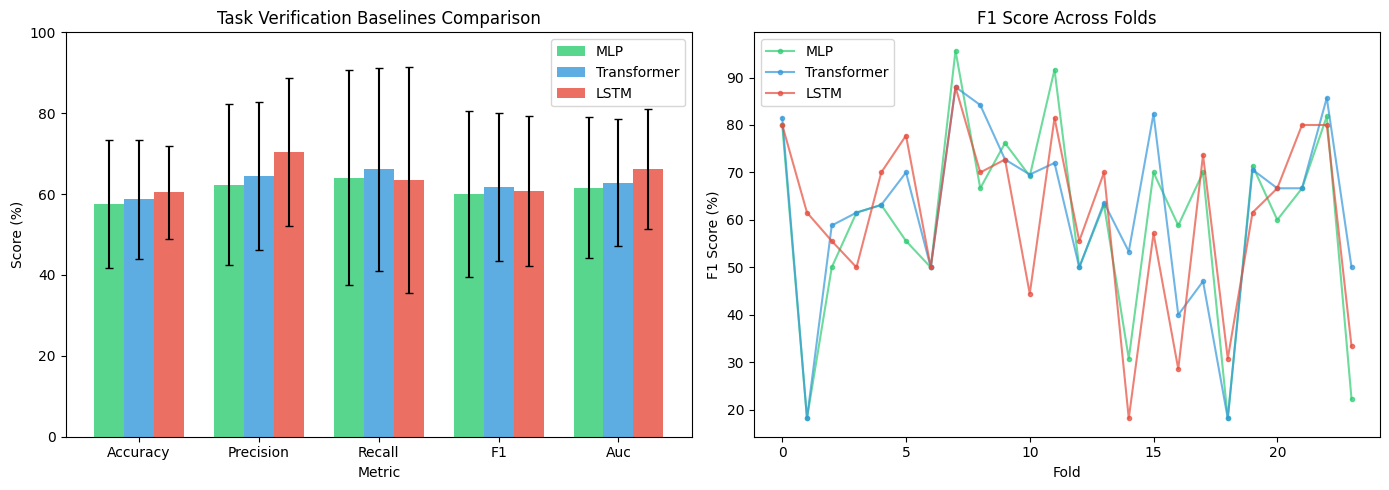

In [ ]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(metrics))
width = 0.25

colors = ['#2ecc71', '#3498db', '#e74c3c']
for i, (model_name, results) in enumerate(all_model_results.items()):
    means = [results[m]['mean'] * 100 for m in metrics]
    stds = [results[m]['std'] * 100 for m in metrics]
    axes[0].bar(x + i*width, means, width, yerr=stds, label=model_name,
                color=colors[i], alpha=0.8, capsize=3)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Task Verification Baselines Comparison')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([m.capitalize() for m in metrics])
axes[0].legend()
axes[0].set_ylim(0, 100)

# F1 Score across folds
for model_name, results_list, color in zip(
    ['MLP', 'Transformer', 'LSTM'],
    [mlp_results, transformer_results, lstm_results],
    colors
):
    f1_scores = [r['f1'] * 100 for r in results_list]
    axes[1].plot(f1_scores, label=model_name, color=color, alpha=0.7, marker='o', markersize=3)

axes[1].set_xlabel('Fold')
axes[1].set_ylabel('F1 Score (%)')
axes[1].set_title('F1 Score Across Folds')
axes[1].legend()

plt.tight_layout()
plt.savefig('extension_data/task_verification_baselines.png', dpi=150)
plt.show()

In [ ]:
# Save results
import json

results_to_save = {
    'summary': all_model_results,
    'mlp_folds': mlp_results,
    'transformer_folds': transformer_results,
    'lstm_folds': lstm_results,
    'config': {
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'batch_size': BATCH_SIZE,
        'pos_weight': POS_WEIGHT,
        'hidden_dim': HIDDEN_DIM,
        'feature_dim': FEATURE_DIM
    }
}

# Convert numpy types for JSON serialization
def convert_numpy(obj):
    import numpy as np

    if isinstance(obj, np.ndarray):
        return obj.tolist()

    elif isinstance(obj, np.integer):
        return int(obj)

    elif isinstance(obj, np.floating):
        return float(obj)

    elif isinstance(obj, np.bool_):
        return bool(obj)

    elif isinstance(obj, dict):
        return {
            key: convert_numpy(value)
            for key, value in obj.items()
        }

    elif isinstance(obj, (list, tuple)):
        return [
            convert_numpy(value)
            for value in obj
        ]

    return obj
with open('extension_data/task_verification_results.json', 'w') as f:
    json.dump(convert_numpy(results_to_save), f, indent=2)

print("Results saved to extension_data/task_verification_results.json")

Results saved to extension_data/task_verification_results.json


## 7. On hyperparameter search

No hyperparameter search is reported for these baselines. One was run and discarded:
324 configurations (108 per model over batch size, learning rate, hidden dimension and
dropout), of which **not one exceeded the 72.76% majority-class F1**.

The search could not have succeeded as constructed. `pos_weight` was fixed at 2.0,
which on this class distribution up-weights the *majority* class; configurations were
ranked by F1, which rewards predicting that majority class for everything; and
checkpoints were selected on training loss with no validation split. The diagnostic is
visible in the LSTM leaderboard, where ranks 2 through 10 all scored **exactly 72.18%**
- nine distinct hyperparameter settings producing bit-identical scores, which happens
only when all of them have collapsed to the same constant predictor.

Section 6 reports the evaluation protocol used instead: nested leave-one-recipe-out with
`pos_weight` derived from each training fold, epoch selection on a held-out validation
split, and balanced accuracy and AUC alongside F1 so that a constant predictor is
visible rather than rewarded.

## Summary

**Substep 2: Task Verification Baselines.**

1. Loaded step-level embeddings from Substep 1
2. Implemented three baselines: MLP (pool + feedforward), Transformer (self-attention
   with a CLS token) and LSTM (bidirectional sequence modelling)
3. Evaluated with nested leave-one-recipe-out cross-validation, reporting metrics pooled
   over all held-out recordings rather than averaged over folds
4. Compared the pipeline under annotated boundaries and under our own ActionFormer's
   predicted boundaries, on the same 384 recordings with identical recipe labels

**The headline result is negative and it is the point.** All three models sit *below* the
majority-class baseline on F1 — the MLP by 8.71 points, the Transformer by 7.97, the LSTM
by 7.87 — with pooled AUC between 59.83% and 62.12%. Recording-level correctness is close
to unlearnable from pooled per-step EgoVLP embeddings at this dataset size.

**Does the boundary source matter here?** Section 9 runs the identical pipeline under
annotated boundaries and under the ActionFormer checkpoint's boundaries, on the same
recordings with identical labels. Read the printed comparison rather than a number quoted
here: the detector was retrained in Substep 1, so any figure written into this cell would
go stale the next time it changes.

What to look for. A sequence model never computes how many canonical steps occurred, so
there is no obvious mechanism for it to gain from oracle boundaries. If the two arms land
within the noise band, that is the expected result and it matters: Substep 4 runs the same
swap on the task-graph representation, where the step count *is* legible, and the contrast
between the two is what identifies the shortcut.

**Note on two GT numbers.** Section 5 and section 9's GT arm build their datasets through
different code paths, and on the previous run they differed by up to 2.5 AUC on identical
recordings. Treat that gap as this pipeline's noise floor and do not quote the two
interchangeably.

**Next**: Substep 3, task-graph encoding and step matching.


## 9. Pipeline Comparison: GT vs ActionFormer Boundaries

Compare Task Verification performance when using Ground Truth boundaries vs ActionFormer predicted boundaries. This shows the impact of automatic step localization on downstream verification accuracy.

In [ ]:
# ==============================================================================
# LOAD BOTH BOUNDARY SOURCES FROM SUBSTEP 1
# ==============================================================================
# Substep 1 exports two files, differing only in where the step boundaries came from:
#
#   step_embeddings_gt.pkl            annotated boundaries - an oracle, because the
#                                     annotation lists only the steps actually performed
#   step_embeddings_actionformer.pkl  boundaries from an ActionFormer checkpoint
#                                     (rohithpeddi/actionformer_release, trained on our
#                                     EgoVLP 1s features), post-processing fitted on the
#                                     validation split only
#
# Both cover the same recordings with identical labels, so the comparison below isolates
# the effect of the boundaries and nothing else.
import os
import pickle
import shutil

print("=" * 70)
print("LOADING GT AND ACTIONFORMER (OURS) STEP EMBEDDINGS")
print("=" * 70)

DRIVE_EXT_DATA = "/content/drive/MyDrive/AML_Project/extension_data"

FILES = {
    "GT": "step_embeddings_gt.pkl",
    "ActionFormer": "step_embeddings_actionformer.pkl",
}

localization_data = {}

for method_name, filename in FILES.items():

    local_path = os.path.join("extension_data", filename)

    # If not local, try copying from Drive
    if not os.path.exists(local_path):
        drive_path = os.path.join(DRIVE_EXT_DATA, filename)

        if os.path.exists(drive_path):
            print(f"Copying {filename} from Drive...")
            os.makedirs("extension_data", exist_ok=True)
            shutil.copy(drive_path, local_path)

    if not os.path.exists(local_path):
        raise FileNotFoundError(
            f"{filename} not found locally or on Drive."
        )

    with open(local_path, "rb") as f:
        loaded = pickle.load(f)

    localization_data[method_name] = loaded["data"]

    print(
        f"{method_name:<15}: "
        f"{len(localization_data[method_name])} recordings"
    )


# ==============================================================================
# FIND COMMON RECORDINGS
# ==============================================================================
# For the GT-vs-ActionFormer comparison, both methods must be evaluated
# on exactly the same videos.

gt_ids = set(localization_data["GT"].keys())
af_ids = set(localization_data["ActionFormer"].keys())

common_ids = gt_ids & af_ids

print("\n" + "=" * 70)
print("MATCHED DATASET")
print("=" * 70)

print(f"GT recordings          : {len(gt_ids)}")
print(f"ActionFormer           : {len(af_ids)}")
print(f"Common recordings      : {len(common_ids)}")


# Restrict both datasets to exactly the same recordings
gt_common = {
    rid: localization_data["GT"][rid]
    for rid in common_ids
}

actionformer_common = {
    rid: localization_data["ActionFormer"][rid]
    for rid in common_ids
}


# Sanity check: labels should be identical
for rid in common_ids:
    assert (
        gt_common[rid]["recipe_label"]
        == actionformer_common[rid]["recipe_label"]
    ), f"Label mismatch for {rid}"

print("Recipe labels are identical across GT and ActionFormer.")

comparison_datasets = {
    "GT": gt_common,
    "ActionFormer": actionformer_common,
}

LOADING GT AND ACTIONFORMER (OURS) STEP EMBEDDINGS
GT             : 384 recordings
Copying step_embeddings_actionformer.pkl from Drive...
ActionFormer   : 384 recordings

MATCHED DATASET
GT recordings          : 384
ActionFormer           : 384
Common recordings      : 384
Recipe labels are identical across GT and ActionFormer.


In [ ]:
# ==============================================================================
# FULL SUBSTEP-2 PIPELINE
# Annotated boundaries vs our ActionFormer's boundaries, on the same 384
# recordings with the same labels, through MLP + Transformer + LSTM.
# ==============================================================================

from collections import defaultdict
import pandas as pd


def build_recipe_groups(data):
    """Group recording IDs by recipe ID."""
    groups = defaultdict(list)

    for recording_id, sample in data.items():
        groups[sample["recipe_id"]].append(recording_id)

    return dict(groups)


# ==============================================================================
# MODEL CONFIGURATIONS
# ==============================================================================

MODEL_CONFIGS = {
    "MLP": {
        "model_class": MLPTaskVerifier,
        "num_epochs": 50,
        "lr": 1e-4,
        "batch_size": 32,
        "model_kwargs": {
            "hidden_dim": 256,
            "dropout": 0.2,
        },
    },

    "Transformer": {
        "model_class": TransformerTaskVerifier,
        "num_epochs": 50,
        "lr": 1e-5,
        "batch_size": 32,
        "model_kwargs": {
            "hidden_dim": 512,
            "num_heads": 4,
            "num_layers": 2,
            "dropout": 0.3,
        },
    },

    "LSTM": {
        "model_class": LSTMTaskVerifier,
        "num_epochs": 50,
        "lr": 1e-5,
        "batch_size": 16,
        "model_kwargs": {
            "hidden_dim": 512,
            "num_layers": 2,
            "dropout": 0.2,
        },
    },
}


# ==============================================================================
# RUN BOTH LOCALIZATION METHODS THROUGH ALL THREE MODELS
# ==============================================================================

pipeline_results = {}

for localization_name, data in comparison_datasets.items():

    print("\n")
    print("=" * 80)
    print(f"LOCALIZATION METHOD: {localization_name}")
    print("=" * 80)

    recipe_groups_local = build_recipe_groups(data)

    sample_id = next(iter(data))
    feature_dim = data[sample_id]["step_embeddings"].shape[1]

    print(f"Recordings : {len(data)}")
    print(f"Recipes    : {len(recipe_groups_local)}")
    print(f"Feature dim: {feature_dim}")

    pipeline_results[localization_name] = {}

    for model_name, config in MODEL_CONFIGS.items():

        print("\n" + "-" * 70)
        print(f"{localization_name} -> {model_name}")
        print("-" * 70)

        results = leave_one_recipe_out_eval(
            model_class=config["model_class"],
            processed_data=data,
            recipe_groups=recipe_groups_local,
            feature_dim=feature_dim,

            num_epochs=config["num_epochs"],
            lr=config["lr"],
            batch_size=config["batch_size"],

            pos_weight="auto",
            tune_threshold=False,
            standardize=True,
            seed=0,

            **config["model_kwargs"],
        )

        if len(results) == 0:
            print(f"No usable folds for {localization_name} + {model_name}")
            continue

        summary = summarize_results(
            results,
            f"{localization_name} + {model_name}"
        )

        pipeline_results[localization_name][model_name] = {
            "folds": results,
            "summary": summary,
        }


# ==============================================================================
# BUILD FINAL COMPARISON TABLE
# ==============================================================================

rows = []

for localization_name, models in pipeline_results.items():

    for model_name, result in models.items():

        pooled = result["summary"]["pooled"]

        rows.append({
            "Localization": localization_name,
            "Model": model_name,
            "Accuracy": pooled["accuracy"],
            "Balanced Accuracy": pooled["balanced_accuracy"],
            "Precision": pooled["precision"],
            "Recall": pooled["recall"],
            "F1": pooled["f1"],
            "AUC": pooled["auc"],
        })


comparison_df = pd.DataFrame(rows)

print("\n")
print("=" * 90)
print("FINAL COMPARISON: ANNOTATED vs OUR PREDICTED BOUNDARIES")
print("=" * 90)

display_df = comparison_df.copy()

metric_cols = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision",
    "Recall",
    "F1",
    "AUC",
]

for col in metric_cols:
    display_df[col] = (
        display_df[col] * 100
    ).map(lambda x: f"{x:.2f}%")

display(display_df)



LOCALIZATION METHOD: GT
Recordings : 384
Recipes    : 24
Feature dim: 256

----------------------------------------------------------------------
GT -> MLP
----------------------------------------------------------------------

Running nested Leave-One-Recipe-Out with 24 folds (4 recipe(s) held out for validation per fold, pos_weight=auto, tune_threshold=False, standardize=True, seed=0)


Folds: 100%|██████████| 24/24 [01:07<00:00,  2.82s/it]



GT + MLP Results (nested Leave-One-Recipe-Out)
POOLED over 384 held-out recordings:
  Accuracy            : 57.29%
  Balanced accuracy   : 56.52%
  Precision           : 62.96%
  Recall              : 61.82%
  F1                  : 62.39%
  Auc                 : 57.96%
  Majority baseline   : F1 72.85%  Acc 57.29%
  Model vs baseline   : F1 -10.46 points
----------------------------------------------------------------
Per-fold mean ± std (variability only, not the headline):
  Accuracy            : 57.06% ± 14.05%
  Balanced accuracy   : 56.61% ± 13.38%
  Precision           : 63.44% ± 16.73%
  Recall              : 61.76% ± 22.53%
  F1                  : 60.04% ± 16.52%
  Auc                 : 59.75% ± 15.83%
----------------------------------------------------------------
  Selected epoch       : mean 22.5 of 50 (min 0, max 49)
  Folds stopping by ep2: 2/24
----------------------------------------------------------------
  Tuned threshold      : mean 0.500 (min 0.50, max 0.50)
  pos

Folds: 100%|██████████| 24/24 [05:26<00:00, 13.61s/it]



GT + Transformer Results (nested Leave-One-Recipe-Out)
POOLED over 384 held-out recordings:
  Accuracy            : 58.85%
  Balanced accuracy   : 58.19%
  Precision           : 64.49%
  Recall              : 62.73%
  F1                  : 63.59%
  Auc                 : 59.34%
  Majority baseline   : F1 72.85%  Acc 57.29%
  Model vs baseline   : F1 -9.25 points
----------------------------------------------------------------
Per-fold mean ± std (variability only, not the headline):
  Accuracy            : 58.47% ± 14.59%
  Balanced accuracy   : 57.86% ± 13.07%
  Precision           : 64.38% ± 13.68%
  Recall              : 62.38% ± 26.03%
  F1                  : 60.20% ± 18.30%
  Auc                 : 59.42% ± 17.87%
----------------------------------------------------------------
  Selected epoch       : mean 21.3 of 50 (min 0, max 49)
  Folds stopping by ep2: 4/24
----------------------------------------------------------------
  Tuned threshold      : mean 0.500 (min 0.50, max 0.50

...

Folds: 100%|██████████| 24/24 [05:27<00:00, 13.63s/it]



ActionFormer + Transformer Results (nested Leave-One-Recipe-Out)
POOLED over 384 held-out recordings:
  Accuracy            : 58.85%
  Balanced accuracy   : 58.43%
  Precision           : 64.90%
  Recall              : 61.36%
  F1                  : 63.08%
  Auc                 : 62.64%
  Majority baseline   : F1 72.85%  Acc 57.29%
  Model vs baseline   : F1 -9.76 points
----------------------------------------------------------------
Per-fold mean ± std (variability only, not the headline):
  Accuracy            : 59.39% ± 14.26%
  Balanced accuracy   : 58.63% ± 12.96%
  Precision           : 65.62% ± 19.42%
  Recall              : 60.54% ± 22.06%
  F1                  : 60.71% ± 18.19%
  Auc                 : 64.95% ± 17.39%
----------------------------------------------------------------
  Selected epoch       : mean 25.1 of 50 (min 0, max 49)
  Folds stopping by ep2: 2/24
----------------------------------------------------------------
  Tuned threshold      : mean 0.500 (min 0.50

Folds: 100%|██████████| 24/24 [07:22<00:00, 18.45s/it]


ActionFormer + LSTM Results (nested Leave-One-Recipe-Out)
POOLED over 384 held-out recordings:
  Accuracy            : 61.20%
  Balanced accuracy   : 60.94%
  Precision           : 67.32%
  Recall              : 62.73%
  F1                  : 64.94%
  Auc                 : 64.10%
  Majority baseline   : F1 72.85%  Acc 57.29%
  Model vs baseline   : F1 -7.91 points
----------------------------------------------------------------
Per-fold mean ± std (variability only, not the headline):
  Accuracy            : 61.46% ± 13.88%
  Balanced accuracy   : 60.78% ± 13.22%
  Precision           : 69.51% ± 17.51%
  Recall              : 62.72% ± 24.29%
  F1                  : 62.08% ± 18.59%
  Auc                 : 66.43% ± 14.07%
----------------------------------------------------------------
  Selected epoch       : mean 32.5 of 50 (min 7, max 49)
  Folds stopping by ep2: 0/24
----------------------------------------------------------------
  Tuned threshold      : mean 0.500 (min 0.50, max 0

,Localization,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,AUC
0,GT,MLP,57.29%,56.52%,62.96%,61.82%,62.39%,57.96%
1,GT,Transformer,58.85%,58.19%,64.49%,62.73%,63.59%,59.34%
2,GT,LSTM,58.59%,58.28%,64.88%,60.45%,62.59%,59.56%
3,ActionFormer,MLP,57.03%,55.98%,62.33%,63.18%,62.75%,62.21%
4,ActionFormer,Transformer,58.85%,58.43%,64.90%,61.36%,63.08%,62.64%
5,ActionFormer,LSTM,61.20%,60.94%,67.32%,62.73%,64.94%,64.10%
